In [1]:
import sys
print(sys.executable)

import graphviz
print("graphviz OK")

/Users/calo/my_project/venv/bin/python3
graphviz OK


In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

ModuleNotFoundError: No module named 'numpy'

In [3]:
pip install numpy

     |████████████████████████████████| 5.3 MB 3.3 MB/s eta 0:00:01
You should consider upgrading via the '/Users/calo/my_project/venv/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [210]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label=label

    
    def __repr__(self):
        return f"Value(data={self.data})"  
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other) #allow to sum int to Value object
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad 
        out._backward = _backward
        
        return out
        
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other) #allow mul int with Value object
        out = Value(self.data * other.data, (self, other), '*')
        
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        
        return out

    def __rmul__(self, other): # other * self
        return self * other

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward

        return out
    
    def __truediv__(self, other): # self / other
        return self * other**-1

    def __neg__(self): # -self
        return self * -1

    def __sub__(self, other): # self - other
        return self + (-other)

    def __radd__(self, other): # other + self
        return self + other
      
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():  
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')

        def _backward():
            self.grad += out.data * out.grad ## out.data is exp(x) just calculated above; out.grad is from the chain rule
        out._backward = _backward

        return out
        
    def backward(self):
        
        topo = []
        visited = set()
        def build_topo(v):
          if v not in visited:
            visited.add(v)
            for child in v._prev:
              build_topo(child)
            topo.append(v)
        build_topo(self)
        
        self.grad = 1.0
        for node in reversed(topo):
          node._backward()


a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value (10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label='L'
#(a.__mul__(b)).__add__(c)
L
#a.exp()
c / a

Value(data=5.0)

In [13]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges


def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    # dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad ), shape='record')  
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot
#draw_dot(d)

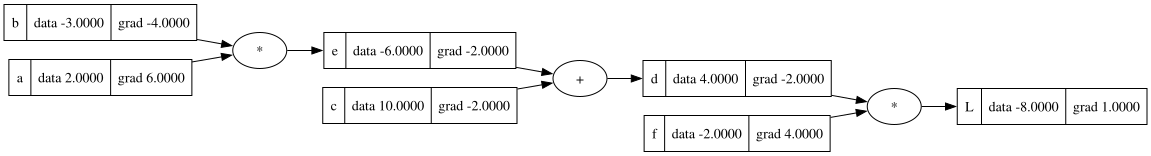

In [67]:
draw_dot(L)  # renders inline automatically in Jupyter

In [66]:
#grad calculated manually 
L.grad = 1
d.grad = f.data * L.grad
f.grad = d.data * L.grad
e.grad = d.grad * 1.0
c.grad = d.grad * 1.0
a.grad = b.data * e.grad
print(a.grad, b.data, e.grad)
b.grad = a.data * e.grad

6.0 -3.0 -2.0


In [40]:
#function to manually check the correctness of grad calculation
def lol():
  
  h = 0.001
  
  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L1 = L.data
  
  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  b.data += h
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L2 = L.data
  
  print((L2 - L1)/h)
  
lol()


-3.9999999999995595


In [68]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f

print(L.data)

-7.286496


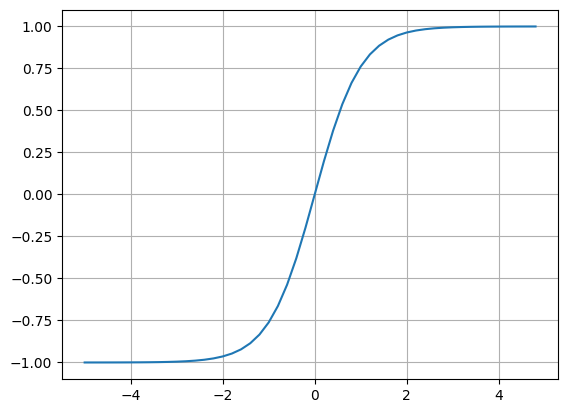

In [42]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

In [212]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

print(o)

Value(data=0.7071067811865476)


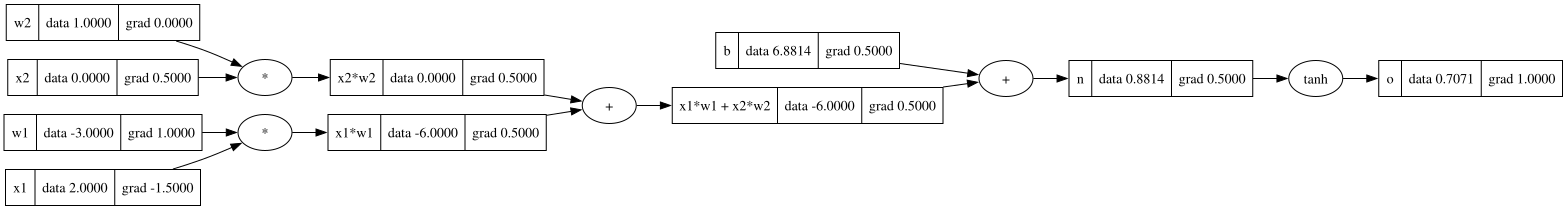

In [216]:
draw_dot(o)

In [214]:
o.grad = 1

In [113]:
# o = tanh(n)
# do / dn = 1 - o**2
n.grad = 1 - o.data**2

In [114]:
b.grad = 0.5
x1w1x2w2.grad = 0.5
x1w1.grad = 0.5
x2w2.grad = 0.5

In [118]:
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad

x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad


#manually calculated grad - lengthy

In [165]:
#using _backward()
o.grad = 1
o._backward() #n.grad


In [169]:
n.grad

0.4999999999999999

In [170]:
n._backward()


In [173]:
b.grad


0.4999999999999999

In [174]:
x1w1x2w2.grad

0.4999999999999999

In [176]:
b._backward()

In [177]:
x1w1x2w2._backward()

In [179]:
x2w2._backward()
x1w1._backward()

In [181]:
topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)
topo

[Value(data=-3.0),
 Value(data=2.0),
 Value(data=-6.0),
 Value(data=0.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=-6.0),
 Value(data=6.881373587019543),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

In [215]:
o.backward()

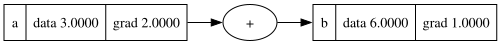

In [190]:
a = Value(3.0, label='a')
b = a + a   ; b.label = 'b'
b.backward()
draw_dot(b)

#this to fix bug in _backward() -> grad to be passed on cumulative via "+="

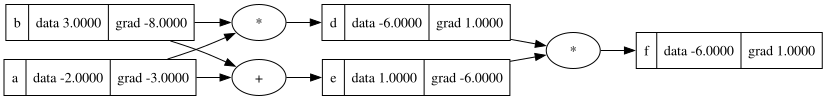

In [191]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b    ; d.label = 'd'
e = a + b    ; e.label = 'e'
f = d * e    ; f.label = 'f'

f.backward()

draw_dot(f)

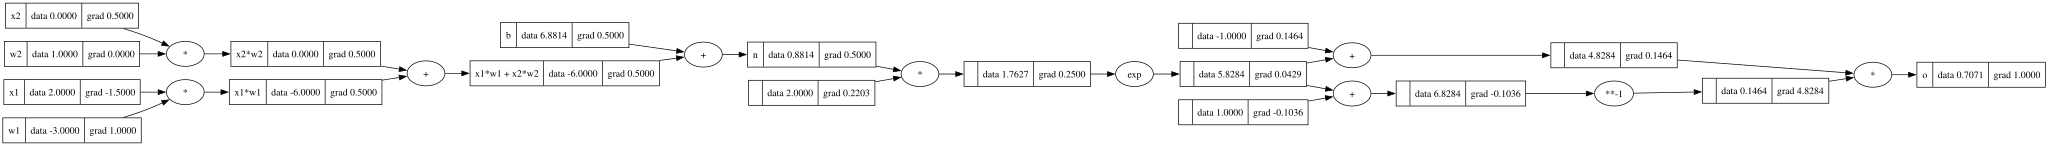

In [218]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# ----
e = (2*n).exp()
o = (e - 1) / (e + 1)
# ----
o.label = 'o'
o.backward()
draw_dot(o)

In [220]:
import torch

In [221]:
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [226]:
import random

In [272]:
class Neuron:
    def __init__(self, nin): #nin = number of inputs of the neuron
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1)) #why no for in b??

    def __call__(self, x):
        # w * x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]
    

class Layer:
  #nout is number of neurons in the layer
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
      
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
  
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
      
    def __call__(self, x):
        for layer in self.layers:
          x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

#x = [2.0, 3.0]
#n = Layer(2, 3)
#x = [2.0, 3.0, -1.0]
#x = [Value(2.0, label='x0'), Value(3.0, label='x1'), Value(-1.0, label='x2')]
#n = MLP(3, [4, 4, 1])
#n(x)
# 3 inputs, 2 hidden layers of 4 neuron each, 1 output
#n(x) #this call __call__

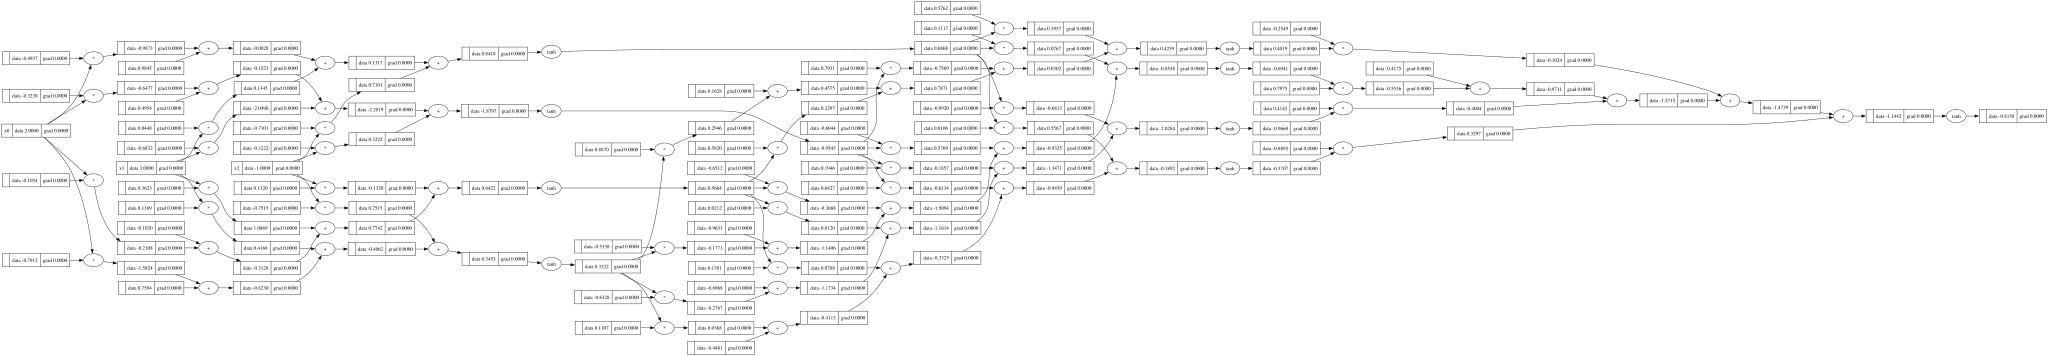

In [243]:
draw_dot(n(x))

In [277]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [278]:
ypred = [n(x) for x in xs]
ypred

[Value(data=0.3680870637928529),
 Value(data=0.606322150486504),
 Value(data=0.5937843588281808),
 Value(data=0.4666569774754105)]

In [279]:
loss = sum((yout-ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=5.804188172210544)

In [280]:
loss.backward()

In [281]:
n.layers[0].neurons[0].w[0].grad

-0.6351546696361993

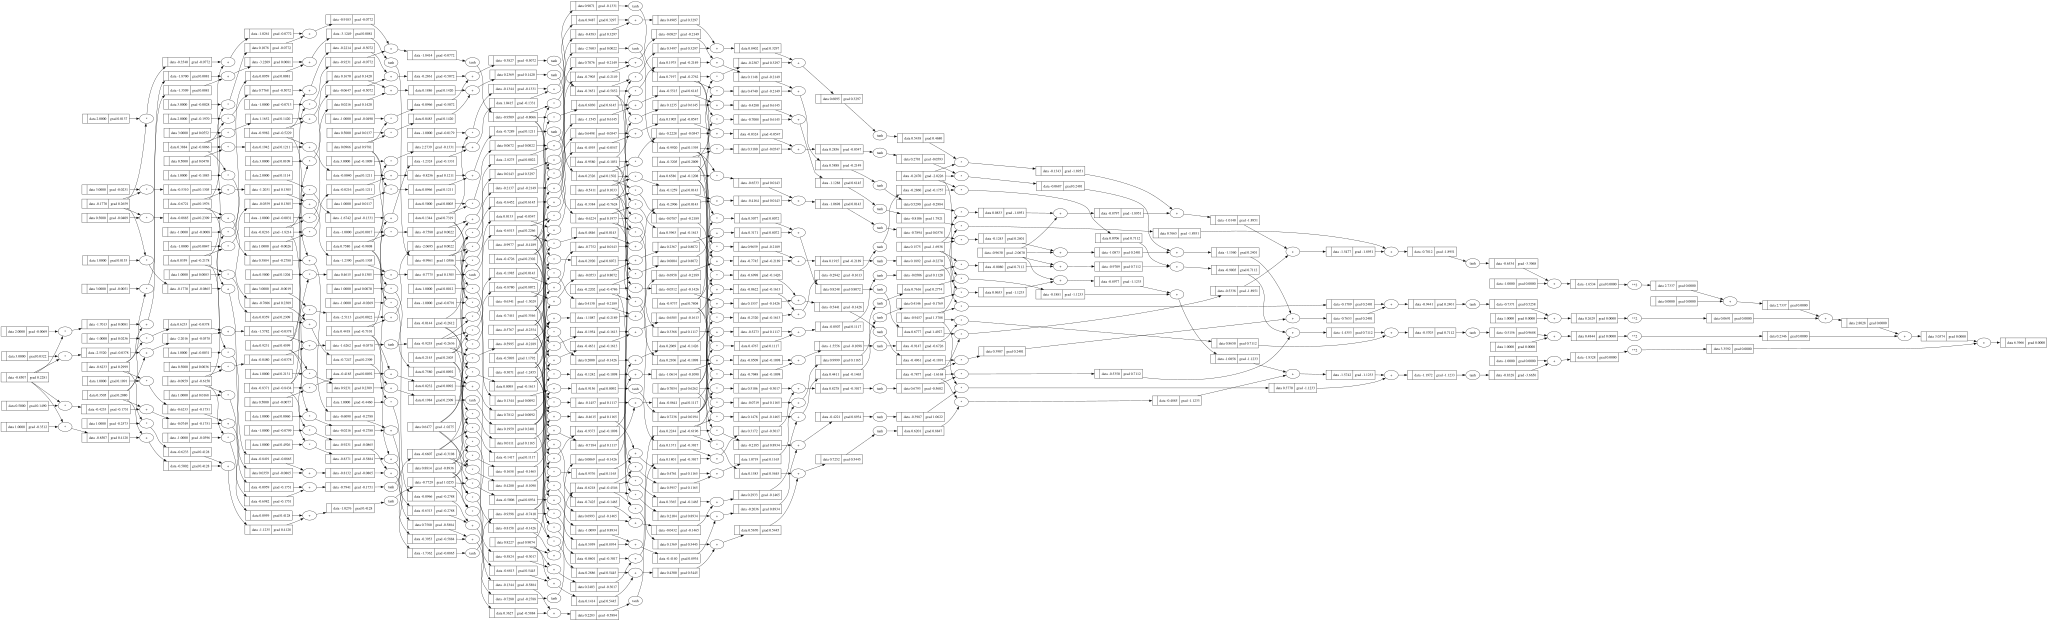

In [259]:
draw_dot(loss)

In [262]:
n.parameters()

AttributeError: 'MLP' object has no attribute 'layer'

In [274]:
x = [Value(2.0, label='x0'), Value(3.0, label='x1'), Value(-1.0, label='x2')]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.3680870637928529)

In [275]:
n.parameters()

[Value(data=0.4741579297494092),
 Value(data=0.6461506218089603),
 Value(data=-0.9768315721063818),
 Value(data=0.02375522088088844),
 Value(data=-0.410077160472073),
 Value(data=0.3025525030659948),
 Value(data=-0.0034197801880306855),
 Value(data=-0.8467051271080588),
 Value(data=-0.6851571933011538),
 Value(data=-0.7499801724803561),
 Value(data=-0.17008423962319896),
 Value(data=0.4990885225447328),
 Value(data=0.7842472776437734),
 Value(data=-0.41240438419719205),
 Value(data=0.6675649165561137),
 Value(data=0.2442624463086891),
 Value(data=0.974702606121645),
 Value(data=-0.8924639924297093),
 Value(data=-0.11655679967067045),
 Value(data=0.801919877940305),
 Value(data=-0.11959373362676007),
 Value(data=0.10331010863862922),
 Value(data=-0.31651053921779604),
 Value(data=0.4604750072781074),
 Value(data=0.38252546273083166),
 Value(data=-0.14931750403705735),
 Value(data=0.28412748766156604),
 Value(data=-0.5916427653741085),
 Value(data=-0.18796242275447494),
 Value(data=-0.04

In [276]:
len(n.parameters())

41

In [285]:
for p in n.parameters():
    p.data += -0.01 * p.grad

In [313]:
ypred = [n(x) for x in xs]
loss = sum((yout-ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=6.372568690377064e-07)

In [311]:
loss.backward()

In [312]:
for p in n.parameters():
    p.data += -0.05 * p.grad

In [314]:
ypred

[Value(data=0.9996362534826846),
 Value(data=-0.9998842107341567),
 Value(data=-0.9994022492244633),
 Value(data=0.9996336228767522)]

In [315]:
n.parameters()

[Value(data=1.436768910186431),
 Value(data=-0.4274197470371045),
 Value(data=-1.3592433131337422),
 Value(data=-0.18512282219687656),
 Value(data=-0.5191331878736608),
 Value(data=2.254661750517926),
 Value(data=-0.4583708669408303),
 Value(data=-0.2995559163560989),
 Value(data=-2.8279539641699705),
 Value(data=-0.2542967939476642),
 Value(data=-2.334362137974665),
 Value(data=-0.6059467030726793),
 Value(data=2.368699709931506),
 Value(data=-3.6575824060612105),
 Value(data=2.7732406207198292),
 Value(data=0.2989949930966195),
 Value(data=0.9002535443724711),
 Value(data=-0.7853346760220296),
 Value(data=0.8704987804341702),
 Value(data=0.3774859725873977),
 Value(data=-1.5432240421298018),
 Value(data=2.450358262726679),
 Value(data=1.6840147997211097),
 Value(data=1.717917095179455),
 Value(data=-3.9854523134589503),
 Value(data=-2.418904822357477),
 Value(data=-4.098595476201147),
 Value(data=-3.068018344237809),
 Value(data=-0.9541114134604473),
 Value(data=6.000152246184365),
 

In [318]:
for k in range(20):

    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout-ygt)**2 for ygt, yout in zip(ys, ypred))

    # backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    # update
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(k, loss.data)

0 5.305154428929676e-17
1 5.305154428929676e-17
2 5.305154428929676e-17
3 5.305154428929676e-17
4 5.305154428929676e-17
5 5.305154428929676e-17
6 5.305154428929676e-17
7 5.305154428929676e-17
8 5.305154428929676e-17
9 5.305154428929676e-17
10 5.305154428929676e-17
11 5.305154428929676e-17
12 5.305154428929676e-17
13 5.305154428929676e-17
14 5.305154428929676e-17
15 5.305154428929676e-17
16 5.305154428929676e-17
17 5.305154428929676e-17
18 5.305154428929676e-17
19 5.305154428929676e-17


In [317]:
ypred

[Value(data=0.9999999999999981),
 Value(data=-0.9999999913997342),
 Value(data=-0.9999999913584303),
 Value(data=0.9999999999999981)]

In [319]:
# zero grad fixed. Reset network

x = [Value(2.0, label='x0'), Value(3.0, label='x1'), Value(-1.0, label='x2')]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.4293866603444342)

In [320]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [321]:
for k in range(20):

    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout-ygt)**2 for ygt, yout in zip(ys, ypred))

    # backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    # update
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(k, loss.data)

0 2.3229373777251228
1 0.6363912514664939
2 0.2872319258793598
3 0.18281457233846626
4 0.13343227300606744
5 0.1045557287128187
6 0.08568056394934202
7 0.07241542254298775
8 0.06260370855156833
9 0.05506448858021186
10 0.04909786043426155
11 0.044263225377444676
12 0.04026969304615728
13 0.036917653774546234
14 0.034065686400920565
15 0.031610862368039075
16 0.029476526777164502
17 0.027604446329119865
18 0.025949608281580404
19 0.02447668337920704


In [322]:
ypred

[Value(data=0.9296657370670722),
 Value(data=-0.9512406562067172),
 Value(data=-0.8877085797736494),
 Value(data=0.9325986782526752)]